<a href="https://colab.research.google.com/github/kjs0904/kjs/blob/main/%EC%9D%B4%EC%83%81%ED%83%90%EC%A7%80(One_class_SVM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

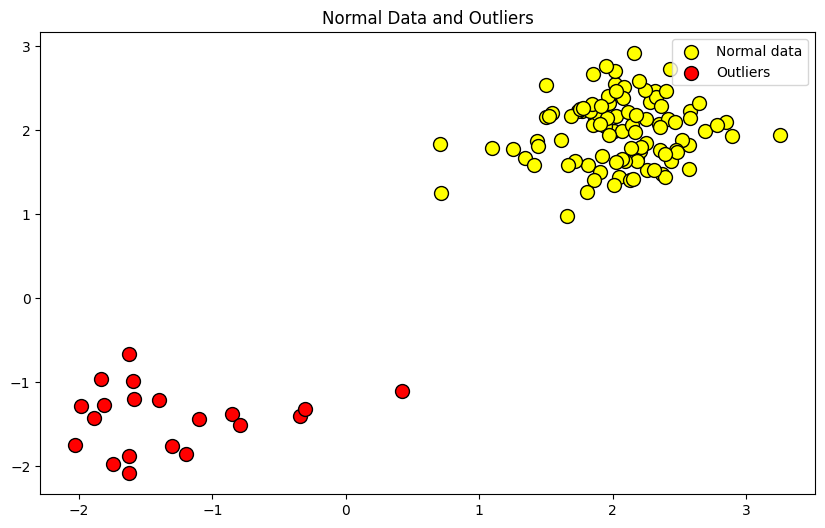

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM

# 시드 고정
np.random.seed(1024)

# 정상 데이터 : 100개 (우상단 (2, 2) 위치 근처)
X_normal = 0.4 * np.random.randn(100, 2) + np.array([2, 2])

# 비정상 데이터 : 20개 (좌하단 (-1.5, -1.5) 위치 근처)
X_outliers = 0.6 * np.random.randn(20, 2) + np.array([-1.5, -1.5])

# 전체 데이터 결합
X = np.vstack([X_normal, X_outliers])

# 시각화
plt.figure(figsize=(10, 6))
plt.scatter(X_normal[:, 0], X_normal[:, 1], c='yellow', edgecolor='k', s=100, label='Normal data')
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c='red', edgecolor='k', s=100, label='Outliers')
plt.title("Normal Data and Outliers")
plt.legend()
plt.show()

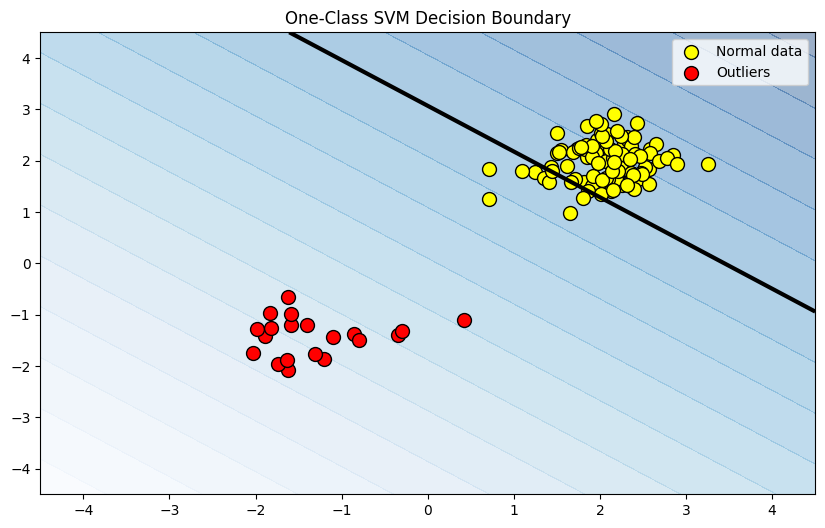

In [2]:
# 1. 모델 생성 및 정상 데이터만으로 학습
oc_svm = OneClassSVM(kernel='linear', gamma='scale', nu=0.1)
oc_svm.fit(X_normal)

# 2. 결정 경계를 그리기 위한 격자(Grid) 데이터 생성 및 점수 계산
xx, yy = np.meshgrid(np.linspace(-4.5, 4.5, 500), np.linspace(-4.5, 4.5, 500))
Z = oc_svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# 3. 학습된 하이퍼플레인 시각화
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, levels=20, cmap='Blues', alpha=0.4)
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=3)
plt.scatter(X_normal[:, 0], X_normal[:, 1], c='yellow', edgecolor='k', s=100, label='Normal data')
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c='red', edgecolor='k', s=100, label='Outliers')
plt.title("One-Class SVM Decision Boundary")
plt.legend()
plt.show()

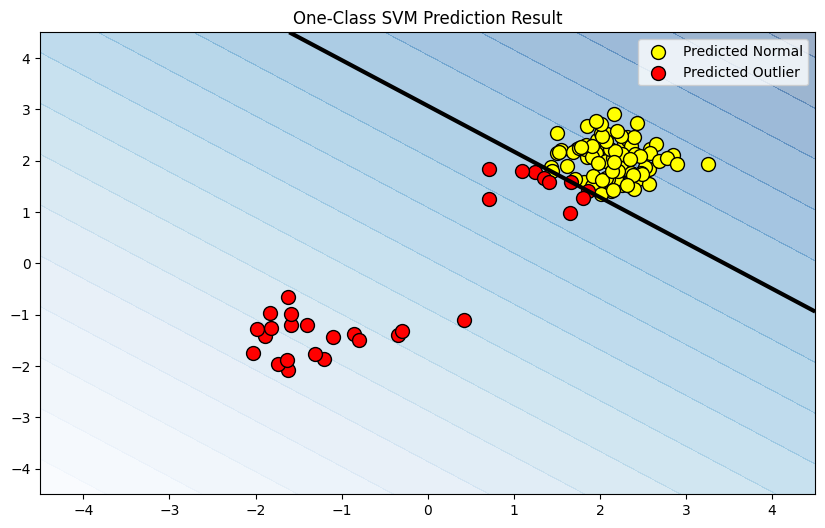

In [3]:
# 전체 데이터에 대한 예측 진행 (정상: 1, 이상치: -1)
y_pred = oc_svm.predict(X)
X_pred_normal = X[y_pred == 1]
X_pred_outlier = X[y_pred == -1]

# 예측 결과 시각화
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, levels=20, cmap='Blues', alpha=0.4)
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=3)

# 모델이 정상으로 분류한 데이터 (노란색)
plt.scatter(X_pred_normal[:, 0], X_pred_normal[:, 1], c='yellow', edgecolor='k', s=100, label='Predicted Normal')
# 모델이 이상치로 분류한 데이터 (빨간색)
plt.scatter(X_pred_outlier[:, 0], X_pred_outlier[:, 1], c='red', edgecolor='k', s=100, label='Predicted Outlier')

plt.title("One-Class SVM Prediction Result")
plt.legend()
plt.show()